In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [6]:
master = pd.read_csv(
    "featured_dataset_v2.csv"
)

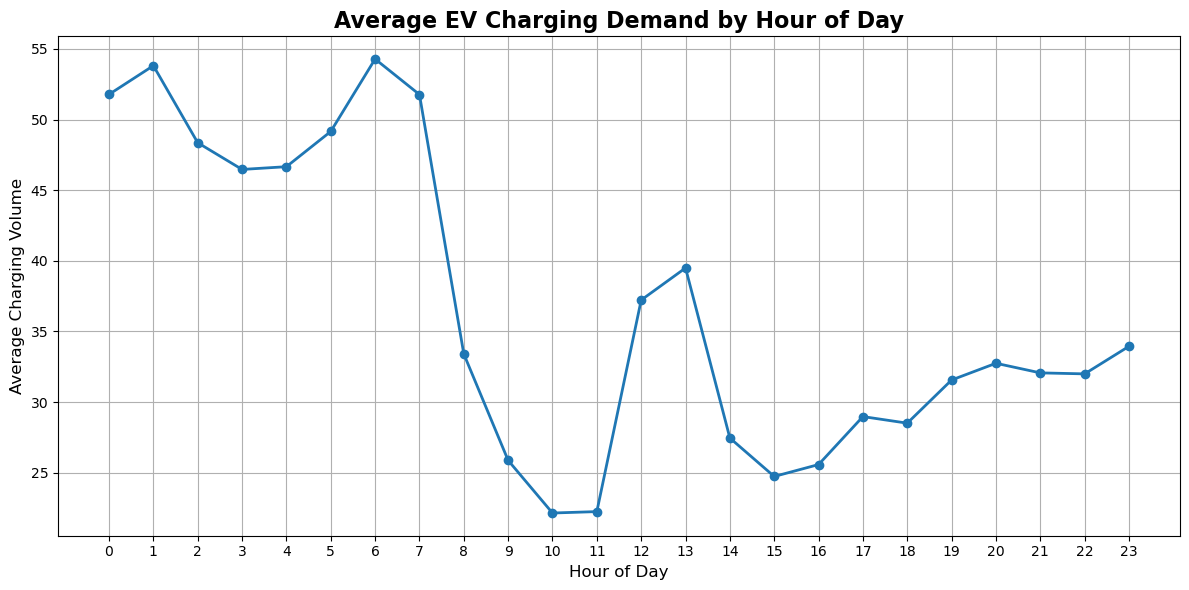

In [10]:
hourly = (
    master.groupby("hour")["volume"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Average EV Charging Demand by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Hour of Day",
    fontsize=12
)

plt.ylabel(
    "Average Charging Volume",
    fontsize=12
)

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()

plt.show()

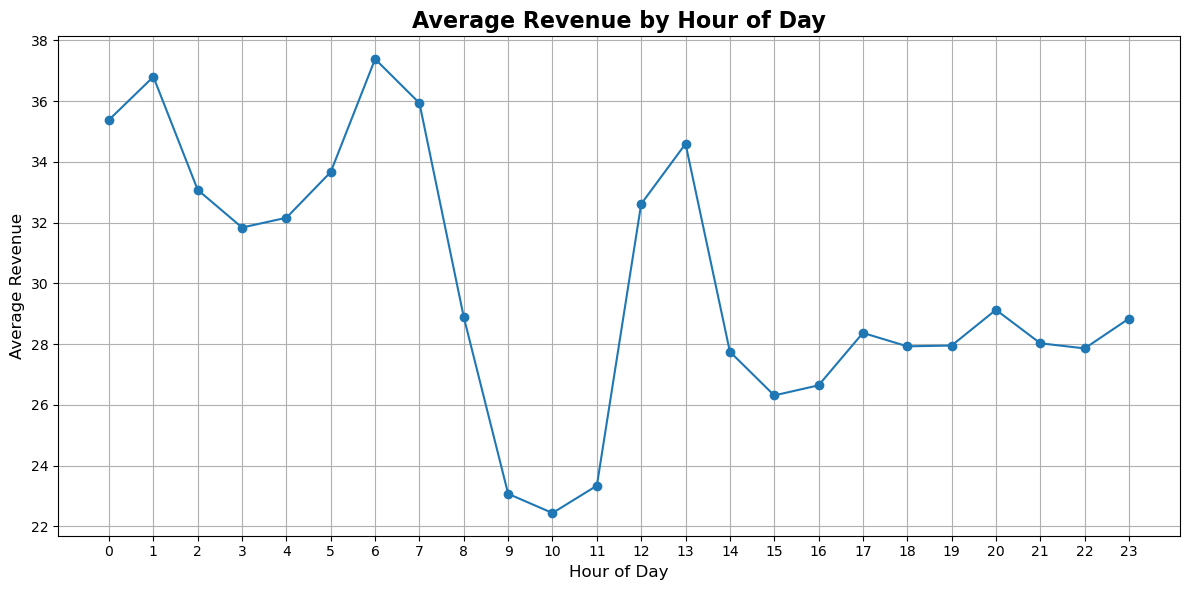

In [11]:
rev = (
    master.groupby("hour")["revenue"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    rev.index,
    rev.values,
    marker='o'
)

plt.title(
    "Average Revenue by Hour of Day",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Hour of Day",
    fontsize=12
)

plt.ylabel(
    "Average Revenue",
    fontsize=12
)

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

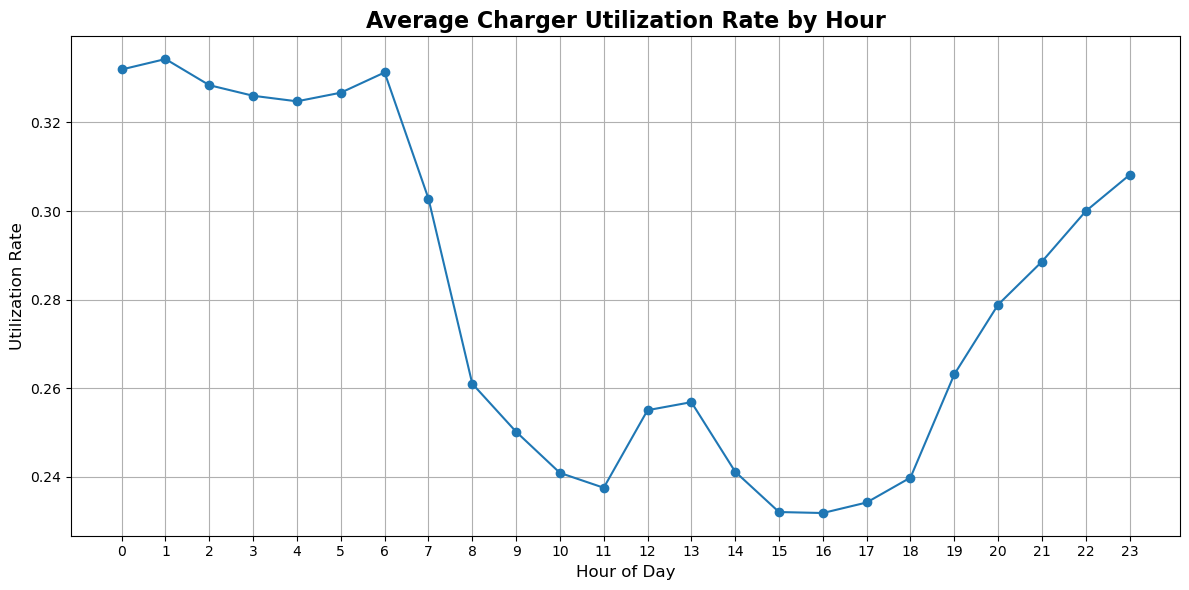

In [12]:
util = (
    master.groupby("hour")["utilization_rate"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    util.index,
    util.values,
    marker='o'
)

plt.title(
    "Average Charger Utilization Rate by Hour",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Hour of Day",
    fontsize=12
)

plt.ylabel(
    "Utilization Rate",
    fontsize=12
)

plt.xticks(range(24))
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
util_table = pd.DataFrame({

    "Hour of Day": util.index,

    "Average Utilization Rate": util.values

})

util_table

,Hour of Day,Average Utilization Rate
0,0,0.331946
1,1,0.334302
2,2,0.328402
3,3,0.326012
4,4,0.324761
5,5,0.326706
6,6,0.331274
7,7,0.302825
8,8,0.261052
9,9,0.250209


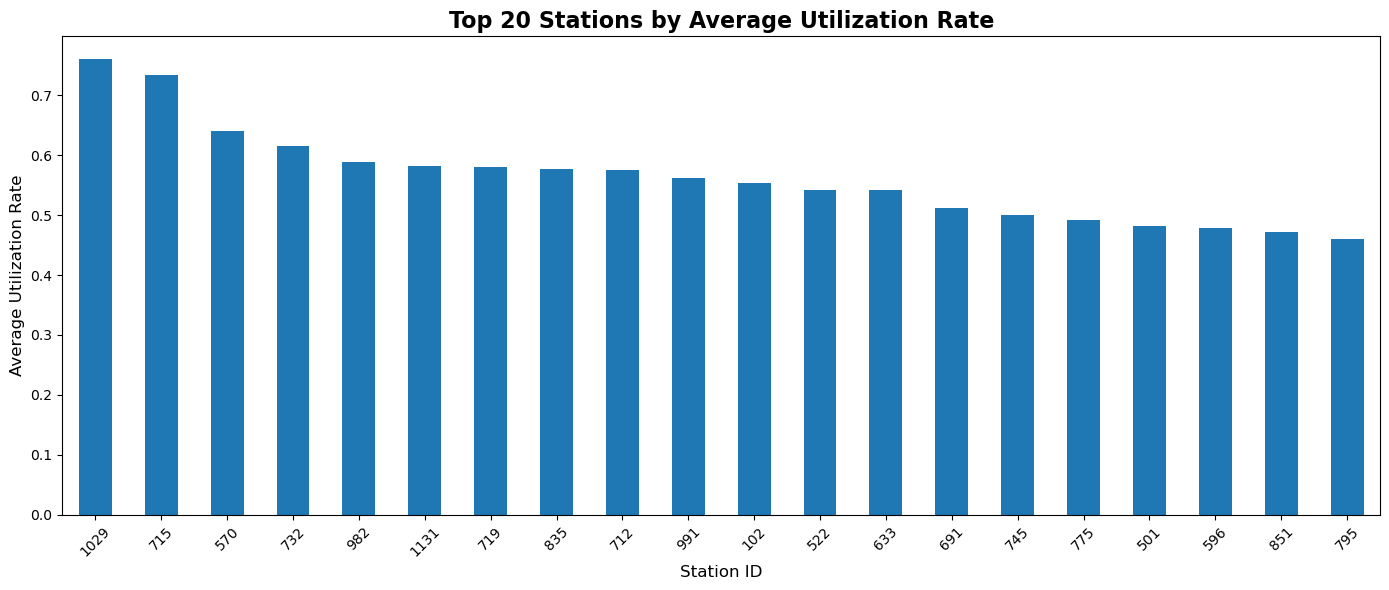

In [6]:
top20 = (
    master.groupby("station_id")["utilization_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(14,6))

top20.plot(kind="bar")

plt.title(
    "Top 20 Stations by Average Utilization Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Station ID",
    fontsize=12
)

plt.ylabel(
    "Average Utilization Rate",
    fontsize=12
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

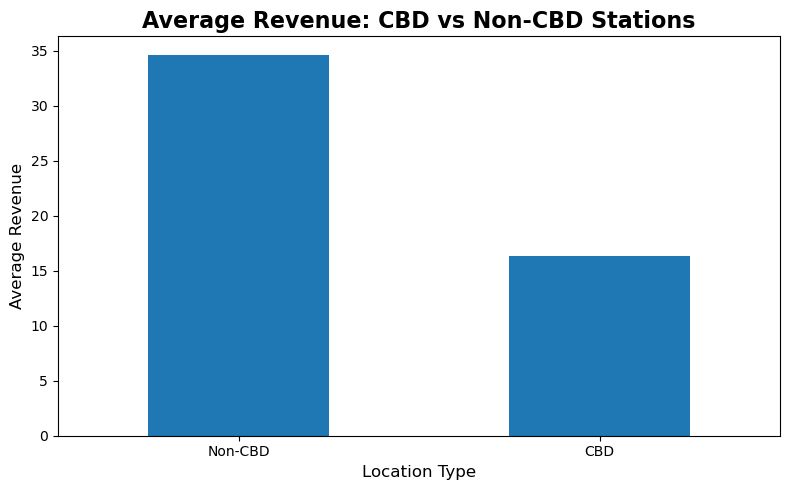

In [7]:
cbd_revenue = (
    master.groupby("CBD")["revenue"]
    .mean()
)

plt.figure(figsize=(8,5))

cbd_revenue.plot(
    kind="bar"
)

plt.title(
    "Average Revenue: CBD vs Non-CBD Stations",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Location Type",
    fontsize=12
)

plt.ylabel(
    "Average Revenue",
    fontsize=12
)

plt.xticks(
    [0,1],
    ["Non-CBD","CBD"],
    rotation=0
)

plt.tight_layout()
plt.show()

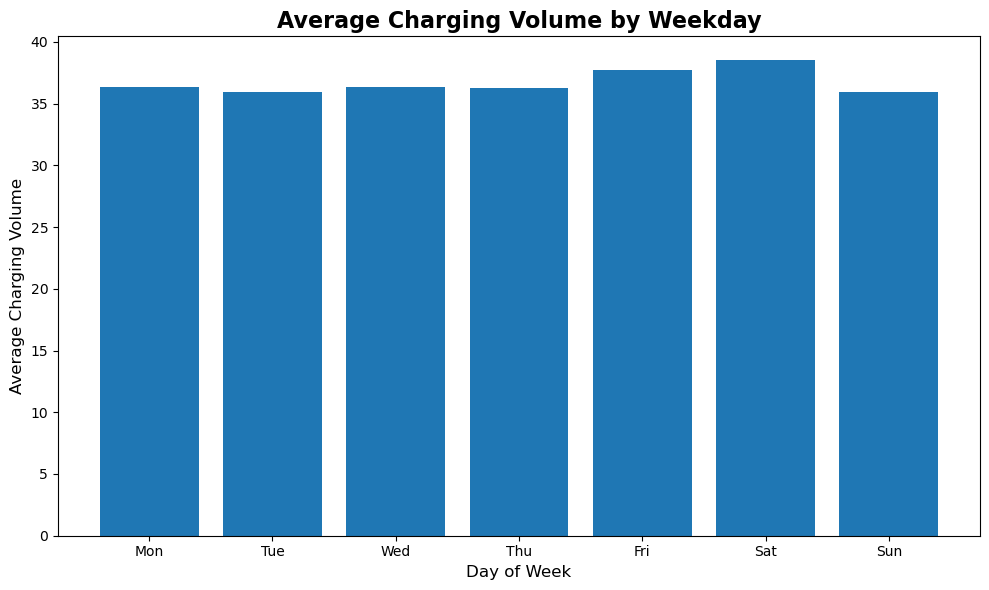

In [8]:
weekday_volume = (
    master.groupby("weekday")["volume"]
    .mean()
)

weekday_names = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]

plt.figure(figsize=(10,6))

plt.bar(
    weekday_names,
    weekday_volume.values
)

plt.title(
    "Average Charging Volume by Weekday",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Day of Week",
    fontsize=12
)

plt.ylabel(
    "Average Charging Volume",
    fontsize=12
)

plt.tight_layout()
plt.show()

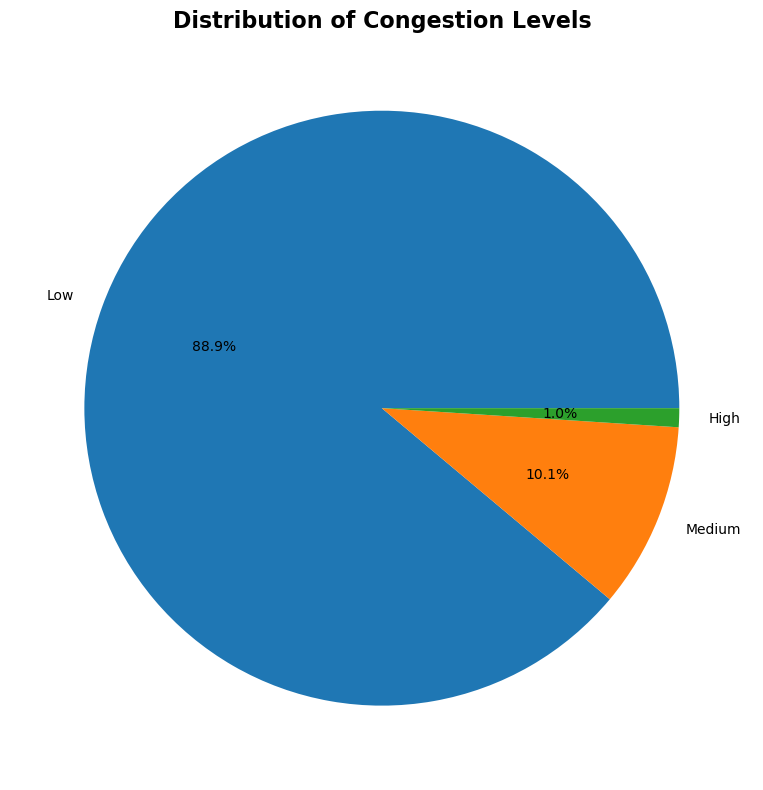

In [9]:
congestion_counts = (
    master["congestion"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    congestion_counts,
    labels=congestion_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Distribution of Congestion Levels",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

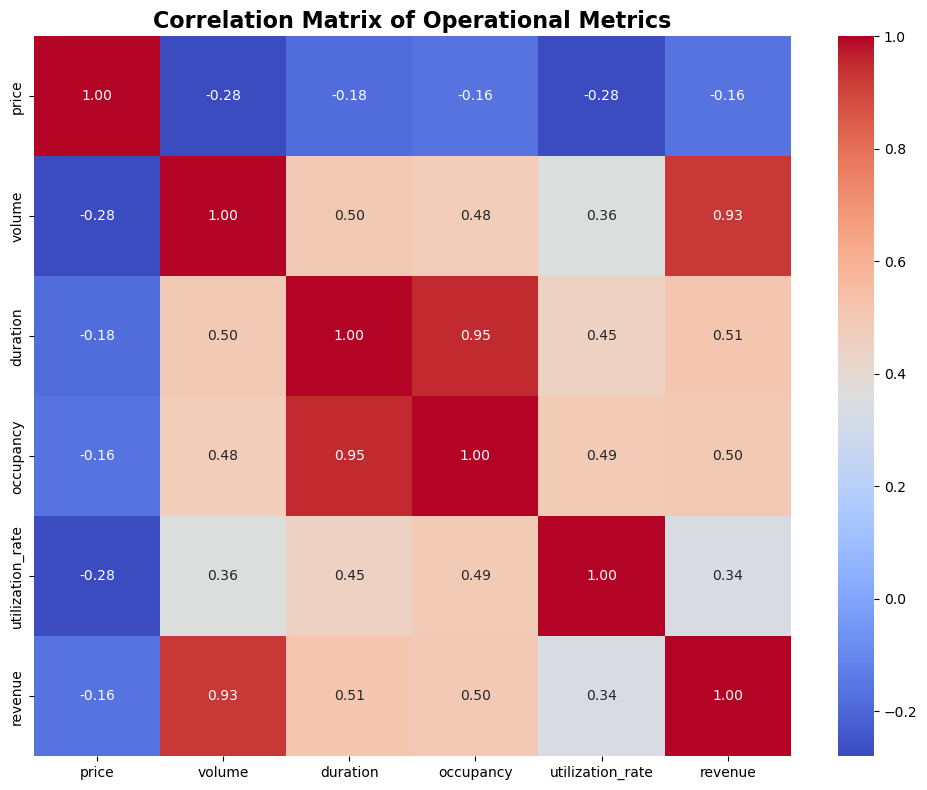

In [10]:
corr = master[
[
    "price",
    "volume",
    "duration",
    "occupancy",
    "utilization_rate",
    "revenue"
]
].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Operational Metrics",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

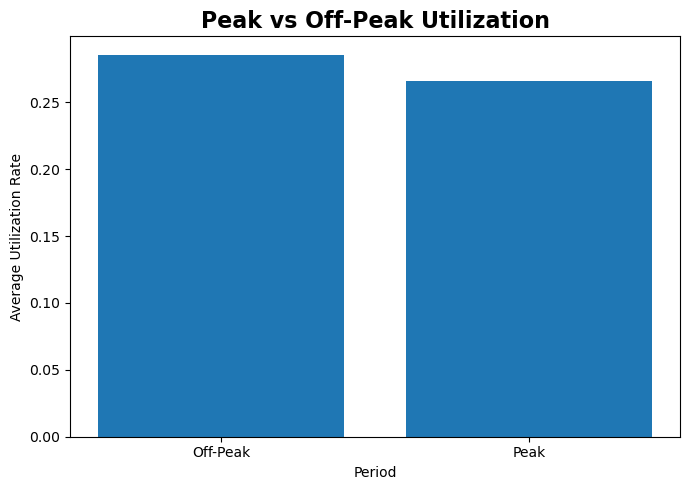

In [11]:
peak_util = (
    master.groupby("peak_hour")
    ["utilization_rate"]
    .mean()
)

plt.figure(figsize=(7,5))

plt.bar(
    ["Off-Peak","Peak"],
    peak_util.values
)

plt.title(
    "Peak vs Off-Peak Utilization",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Utilization Rate")

plt.tight_layout()
plt.show()

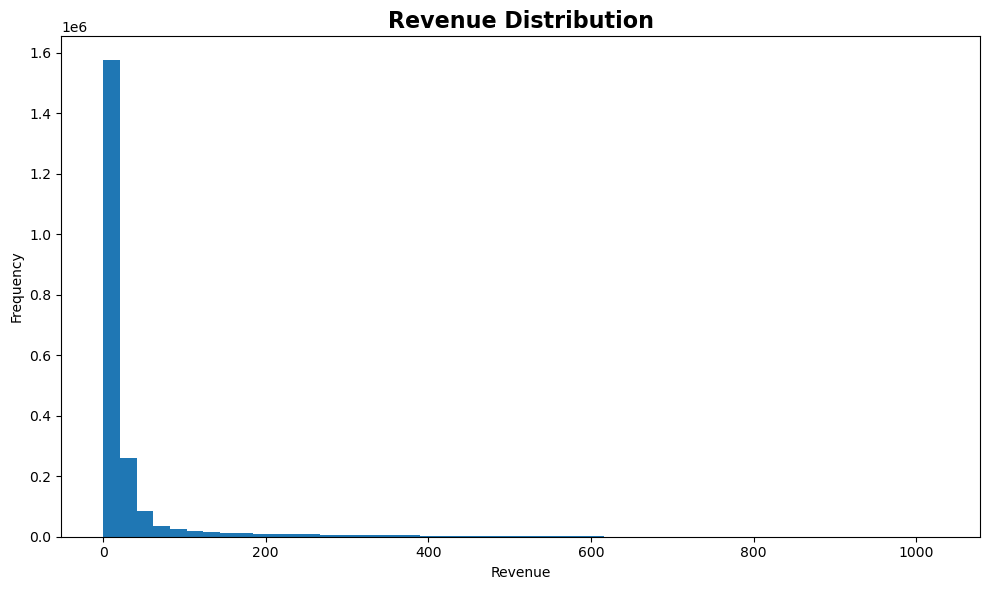

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    master["revenue"],
    bins=50
)

plt.title(
    "Revenue Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

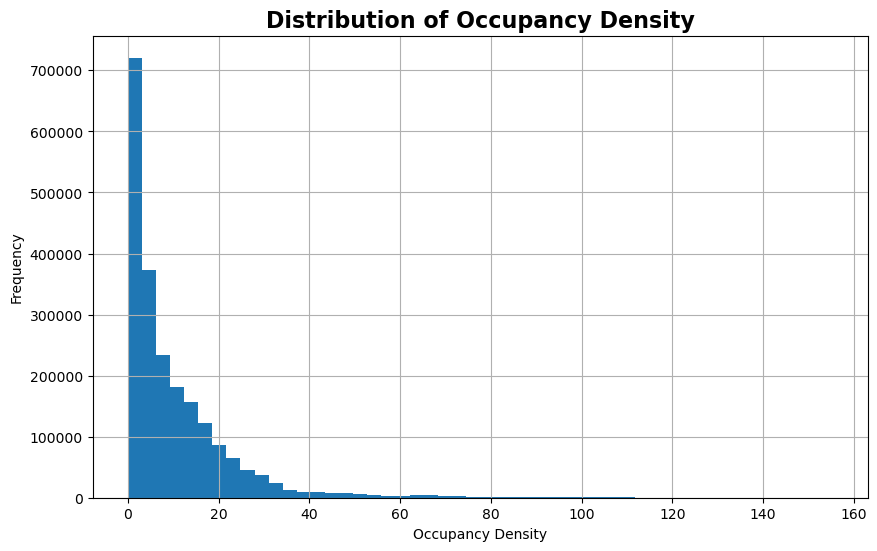

In [13]:
plt.figure(figsize=(10,6))

master["occupancy_density"].hist(
    bins=50
)

plt.title(
    "Distribution of Occupancy Density",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Occupancy Density")
plt.ylabel("Frequency")

plt.show()

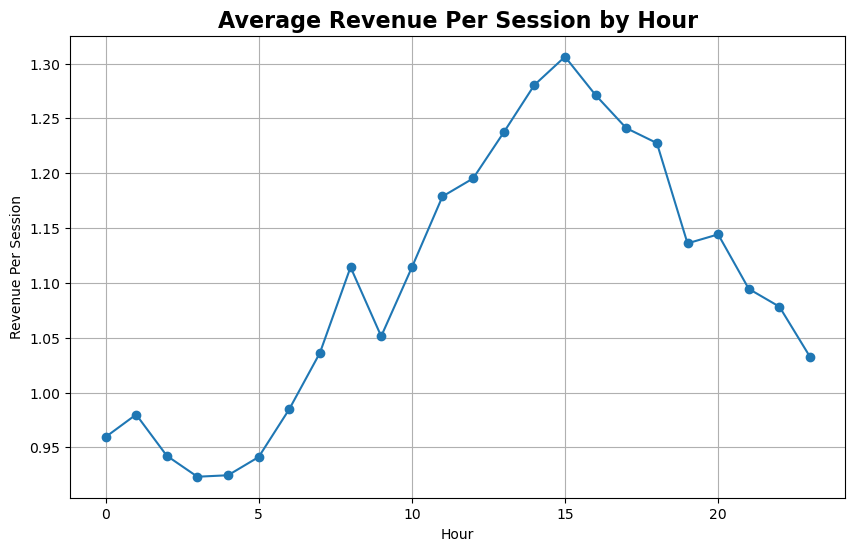

In [15]:
rev_session = (
    master.groupby("hour")
    ["revenue_per_session"]
    .mean()
)

plt.figure(figsize=(10,6))

plt.plot(
    rev_session.index,
    rev_session.values,
    marker="o"
)

plt.title(
    "Average Revenue Per Session by Hour",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Revenue Per Session")

plt.grid(True)

plt.show()

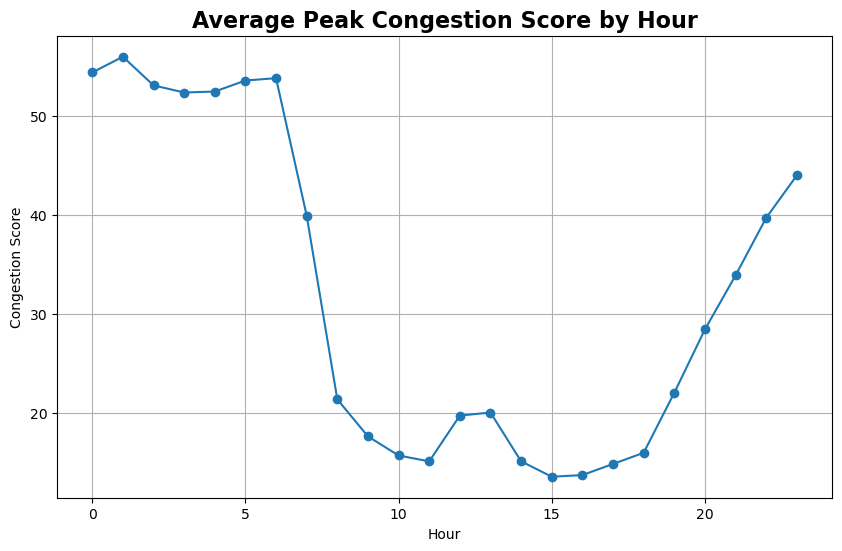

In [16]:
peak_score = (
    master.groupby("hour")
    ["peak_congestion_score"]
    .mean()
)

plt.figure(figsize=(10,6))

plt.plot(
    peak_score.index,
    peak_score.values,
    marker="o"
)

plt.title(
    "Average Peak Congestion Score by Hour",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Congestion Score")

plt.grid(True)

plt.show()

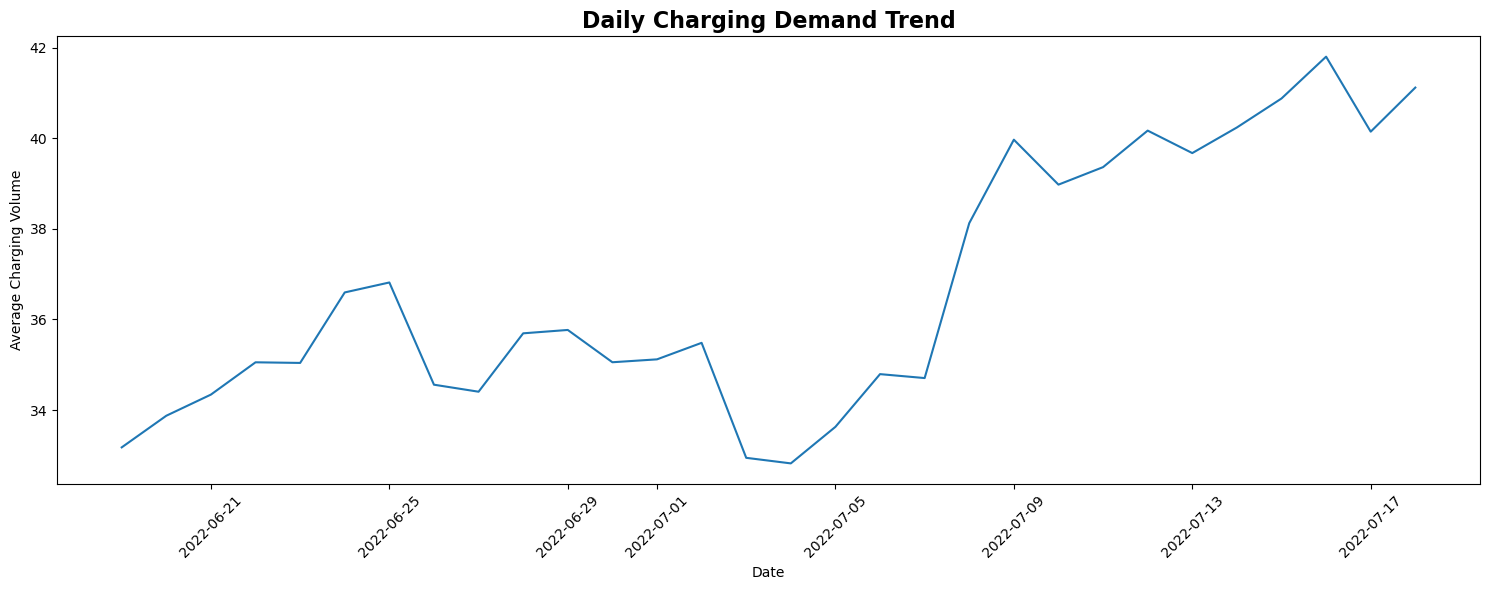

In [17]:
master["datetime"] = pd.to_datetime(master["datetime"])

daily_demand = (
    master.groupby(
        master["datetime"].dt.date
    )["volume"]
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title(
    "Daily Charging Demand Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Average Charging Volume")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

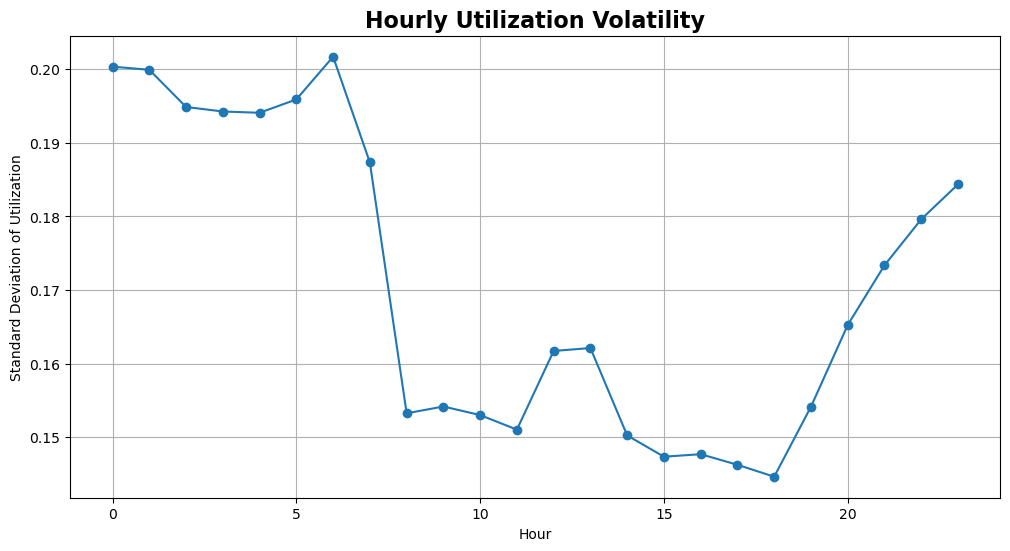

In [18]:
util_std = (
    master.groupby("hour")
    ["utilization_rate"]
    .std()
)

plt.figure(figsize=(12,6))

plt.plot(
    util_std.index,
    util_std.values,
    marker="o"
)

plt.title(
    "Hourly Utilization Volatility",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hour")
plt.ylabel("Standard Deviation of Utilization")

plt.grid(True)

plt.show()

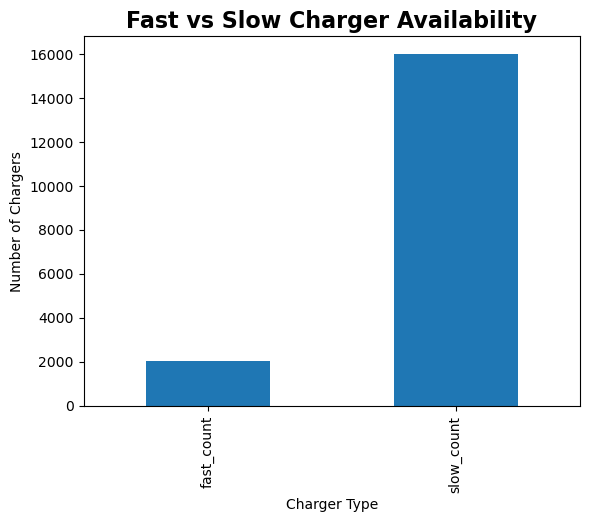

In [19]:
charger_mix = (
    master.groupby("station_id")
    [["fast_count","slow_count"]]
    .first()
)

charger_mix.sum().plot(
    kind="bar"
)

plt.title(
    "Fast vs Slow Charger Availability",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Charger Type")
plt.ylabel("Number of Chargers")

plt.show()

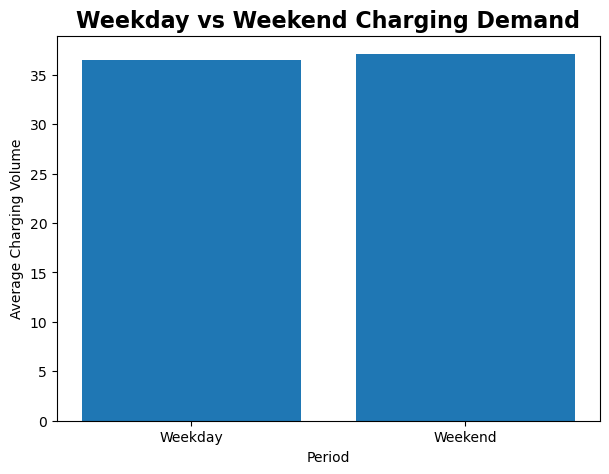

In [20]:
weekend_analysis = (
    master.groupby("weekend")
    ["volume"]
    .mean()
)

plt.figure(figsize=(7,5))

plt.bar(
    ["Weekday","Weekend"],
    weekend_analysis.values
)

plt.title(
    "Weekday vs Weekend Charging Demand",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Period")
plt.ylabel("Average Charging Volume")

plt.show()

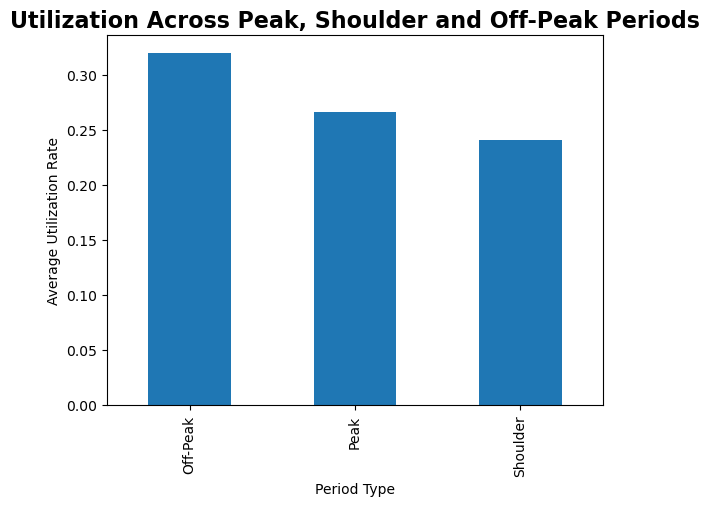

In [21]:
period_util = (
    master.groupby("period_type")
    ["utilization_rate"]
    .mean()
)

period_util.plot(
    kind="bar"
)

plt.title(
    "Utilization Across Peak, Shoulder and Off-Peak Periods",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Period Type")
plt.ylabel("Average Utilization Rate")

plt.show()

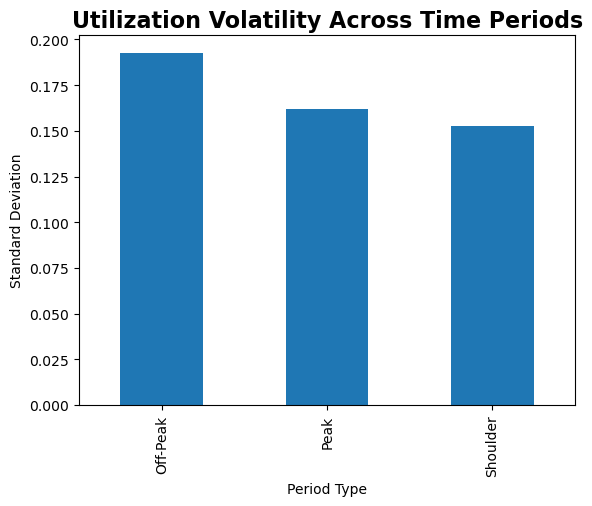

In [22]:
period_std = (
    master.groupby("period_type")
    ["utilization_rate"]
    .std()
)

period_std.plot(
    kind="bar"
)

plt.title(
    "Utilization Volatility Across Time Periods",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Period Type")
plt.ylabel("Standard Deviation")

plt.show()

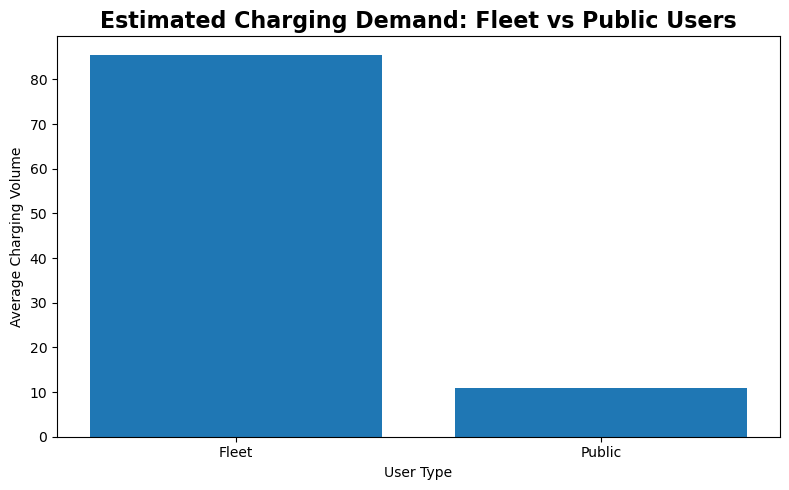

In [23]:
fleet_public = (
    master.groupby("user_type_proxy")
    ["volume"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.bar(
    fleet_public.index,
    fleet_public.values
)

plt.title(
    "Estimated Charging Demand: Fleet vs Public Users",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("User Type")
plt.ylabel("Average Charging Volume")

plt.tight_layout()
plt.show()

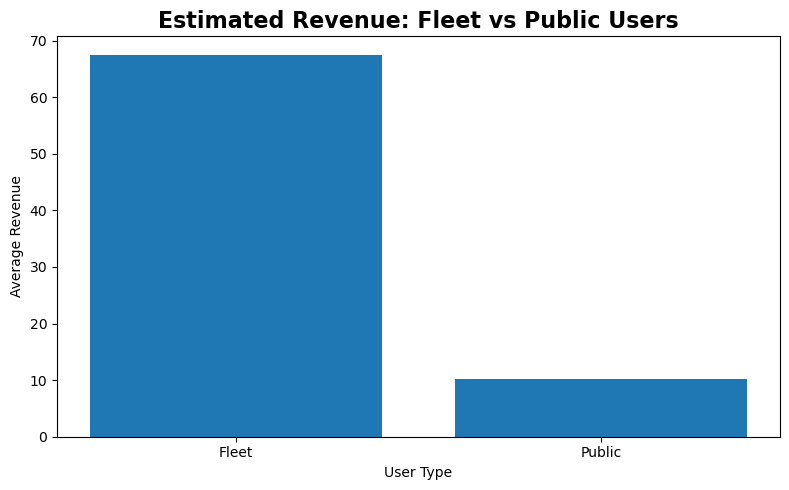

In [24]:
fleet_rev = (
    master.groupby("user_type_proxy")
    ["revenue"]
    .mean()
)

plt.figure(figsize=(8,5))

plt.bar(
    fleet_rev.index,
    fleet_rev.values
)

plt.title(
    "Estimated Revenue: Fleet vs Public Users",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("User Type")
plt.ylabel("Average Revenue")

plt.tight_layout()
plt.show()

In [25]:
print(master.shape)

master.info()

(2134080, 38)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2134080 entries, 0 to 2134079
Data columns (total 38 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   timestamp              int64         
 1   station_id             int64         
 2   price                  float64       
 3   occupancy              int64         
 4   volume                 float64       
 5   duration               float64       
 6   month                  int64         
 7   day                    int64         
 8   year                   int64         
 9   hour                   int64         
 10  minute                 int64         
 11  second                 int64         
 12  datetime               datetime64[ns]
 13  num                    int64         
 14  count                  int64         
 15  fast_count             int64         
 16  slow_count             int64         
 17  area                   float64       
 18  lon     